# Spatial Point Process — Improved Models

This notebook extends `spatial_pp.ipynb` with two concrete improvements:

| Improvement | Why |
|-------------|-----|
| **Spatial coordinates as covariates** | The baseline M2 treats all 400 cells as exchangeable draws from the same prior — it has no notion of where a cell sits on the map. Adding normalised lat/lon as covariates lets the model learn a smooth global spatial trend (e.g. crime higher in the north-east). |
| **Negative Binomial likelihood** | Poisson forces variance = mean. Crime counts are strongly **overdispersed** — the Tenderloin has 19,000 training incidents while peripheral cells have near-zero. Negative Binomial adds a dispersion parameter that lets variance grow faster than the mean, producing better-calibrated uncertainty. |

### Models

| Label | Likelihood | Spatial covariates | Pooling |
|-------|------------|-------------------|---------|
| M1    | Poisson    | no                | none    |
| M2    | Poisson    | no                | partial |
| M3    | Poisson    | yes (lat + lon)   | partial |
| M4    | Neg-Binom  | no                | partial |
| M5    | Neg-Binom  | yes (lat + lon)   | partial |

M1 and M2 are reproduced from `spatial_pp.ipynb` as baselines.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import ClippedAdam

pyro.set_rng_seed(42)
torch.set_default_dtype(torch.float32)
print("Pyro", pyro.__version__, "| Torch", torch.__version__)

Pyro 1.9.1 | Torch 2.8.0


## 1  Data & Grid  *(same as `spatial_pp.ipynb`)*

In [2]:
DATA_PATH = "../../data/processed/incidents_2018_2025.csv"
LAT_MIN, LAT_MAX = 37.70, 37.84
LON_MIN, LON_MAX = -122.53, -122.35

df = pd.read_csv(DATA_PATH, low_memory=False)
df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"])
df = df.dropna(subset=["Latitude", "Longitude"])
df = df[df["Latitude"].between(LAT_MIN, LAT_MAX) &
        df["Longitude"].between(LON_MIN, LON_MAX)].copy()

TRAIN_YEARS_LIST = [2021, 2022, 2023]
TEST_YEARS_LIST  = [2024, 2025]
TRAIN_YEARS = len(TRAIN_YEARS_LIST)
TEST_YEARS  = len(TEST_YEARS_LIST)

df_train = df[df["Incident Datetime"].dt.year.isin(TRAIN_YEARS_LIST)].copy()
df_test  = df[df["Incident Datetime"].dt.year.isin(TEST_YEARS_LIST)].copy()

print(f"Train: {len(df_train):,}  |  Test: {len(df_test):,}")

Train: 366,384  |  Test: 194,241


In [3]:
GRID_SIZE = 20
N_CELLS   = GRID_SIZE ** 2

lat_edges = np.linspace(LAT_MIN, LAT_MAX, GRID_SIZE + 1)
lon_edges = np.linspace(LON_MIN, LON_MAX, GRID_SIZE + 1)
lat_mid   = (lat_edges[:-1] + lat_edges[1:]) / 2
lon_mid   = (lon_edges[:-1] + lon_edges[1:]) / 2

LON_GRID, LAT_GRID = np.meshgrid(lon_mid, lat_mid)
centroids = np.stack([LAT_GRID.ravel(), LON_GRID.ravel()], axis=1)

def assign_cell(df_in):
    lat_idx = np.clip(np.digitize(df_in["Latitude"].values,  lat_edges) - 1, 0, GRID_SIZE-1)
    lon_idx = np.clip(np.digitize(df_in["Longitude"].values, lon_edges) - 1, 0, GRID_SIZE-1)
    return lat_idx * GRID_SIZE + lon_idx

counts_tr = np.bincount(assign_cell(df_train), minlength=N_CELLS).astype(np.float32)
counts_te = np.bincount(assign_cell(df_test),  minlength=N_CELLS).astype(np.float32)

# Weekly test matrix for evaluation
df_test_c = df_test.copy()
df_test_c["cell"] = assign_cell(df_test_c)
df_test_c["week"] = df_test_c["Incident Datetime"].dt.to_period("W")
weekly_te_arr = (
    df_test_c.groupby(["week", "cell"]).size()
    .unstack(fill_value=0)
    .reindex(columns=range(N_CELLS), fill_value=0)
    .values.astype(np.float32)
)
N_WEEKS_TE = len(weekly_te_arr)

# Tensors
y_tr = torch.tensor(counts_tr)
y_te = torch.tensor(counts_te)
log_exp_tr = torch.log(torch.tensor(float(TRAIN_YEARS)))
log_exp_te = torch.log(torch.tensor(float(TEST_YEARS)))

# Normalised coordinates — shape [N_CELLS, 2]
X = torch.tensor(
    np.stack([(centroids[:, 0] - LAT_MIN) / (LAT_MAX - LAT_MIN),
              (centroids[:, 1] - LON_MIN) / (LON_MAX - LON_MIN)], axis=1),
    dtype=torch.float32)

print(f"Grid: {GRID_SIZE}×{GRID_SIZE} = {N_CELLS} cells")
print(f"X shape: {X.shape}  (normalised lat, lon per cell)")
print(f"Train mean/max: {counts_tr.mean():.0f} / {counts_tr.max():.0f}")

Grid: 20×20 = 400 cells
X shape: torch.Size([400, 2])  (normalised lat, lon per cell)
Train mean/max: 916 / 19352


In [4]:
# ── Param-store save / restore ────────────────────────────────────────────────
def save_guide(guide):
    _, guide._param_file = tempfile.mkstemp(suffix=".pth")
    pyro.get_param_store().save(guide._param_file)

def restore_guide(guide):
    pyro.clear_param_store()
    state = torch.load(guide._param_file, weights_only=False)
    pyro.get_param_store().set_state(state)

def train_svi(model, guide, n_steps=8000, lr=0.01, log_every=2000, **kwargs):
    pyro.set_rng_seed(42); pyro.clear_param_store()
    svi    = SVI(model, guide, ClippedAdam({"lr": lr, "lrd": 0.1**(1/n_steps)}),
                 loss=Trace_ELBO())
    losses = []
    for step in range(1, n_steps + 1):
        losses.append(svi.step(**kwargs))
        if step % log_every == 0:
            print(f"  step {step:>6d}  ELBO = {-losses[-1]:+,.0f}")
    save_guide(guide)
    return losses

---
## 2  Model Definitions

### M1 — Homogeneous Poisson (null baseline)

$$
\log\lambda \sim \mathcal{N}(0, 3^2)
\qquad
N_c \sim \text{Poisson}(e^{\log\lambda} \cdot T) \quad \forall\, c
$$

Every cell shares one rate. Crime is assumed spatially uniform — clearly
wrong, but useful as a lower bound on model quality.

---

### M2 — Hierarchical Poisson (baseline from `spatial_pp.ipynb`)

$$
\mu \sim \mathcal{N}(0, 3^2), \quad \sigma \sim \text{HalfNormal}(1.5)
$$
$$
\log\lambda_c \sim \mathcal{N}(\mu,\, \sigma^2)
\qquad
N_c \sim \text{Poisson}(\lambda_c \cdot T)
$$

Each cell has its own rate, pooled through a shared prior. The prior mean
$\mu$ is constant across all cells — the model still has **no spatial
awareness**: it doesn't know cell (3, 7) is next to cell (3, 8).

---

### M3 — Hierarchical Poisson + Spatial Covariates

$$
\boldsymbol{\beta} \sim \mathcal{N}(\mathbf{0}, 3^2 \mathbf{I}_2)
$$
$$
\log\lambda_c \sim \mathcal{N}\!\left(\mathbf{x}_c^\top\boldsymbol{\beta} + \mu,\; \sigma^2\right)
\qquad
N_c \sim \text{Poisson}(\lambda_c \cdot T)
$$

where $\mathbf{x}_c = [\hat{\text{lat}}_c,\; \hat{\text{lon}}_c]^\top$ are
normalised coordinates of cell $c$.

The term $\mathbf{x}_c^\top\boldsymbol{\beta}$ adds a **global linear spatial
trend** — the model can learn e.g. that crime increases as you move east or
south. The per-cell offset $\log\lambda_c$ still captures local deviations
above/below the trend, with partial pooling through $\sigma$.

---

### M4 — Hierarchical Negative Binomial

$$
\mu \sim \mathcal{N}(0, 3^2), \quad \sigma \sim \text{HalfNormal}(1.5),
\quad r \sim \text{Gamma}(2, 0.5)
$$
$$
\log\lambda_c \sim \mathcal{N}(\mu,\, \sigma^2)
\qquad
N_c \sim \text{NegBin}(r,\; p_c = \tfrac{\lambda_c}{r + \lambda_c})
$$

The **Negative Binomial** is equivalent to a Poisson model where each cell's
rate is itself a Gamma-distributed random variable:

$$
\tilde{\lambda}_c \sim \text{Gamma}(r,\, r/\lambda_c)
\qquad
N_c \mid \tilde{\lambda}_c \sim \text{Poisson}(\tilde{\lambda}_c \cdot T)
$$

Marginalising out $\tilde{\lambda}_c$ gives NegBin with $\text{Var}[N_c] =
\lambda_c + \lambda_c^2/r$.  As $r \to \infty$ this collapses to Poisson.
The learnt $r$ tells us **how overdispersed** the data really is.

---

### M5 — Hierarchical Negative Binomial + Spatial Covariates

Combines M3 (linear spatial trend) and M4 (overdispersion):

$$
\log\lambda_c \sim \mathcal{N}\!\left(\mathbf{x}_c^\top\boldsymbol{\beta} + \mu,\; \sigma^2\right)
\qquad
N_c \sim \text{NegBin}(r,\; p_c)

In [5]:
# ── M1: homogeneous Poisson ───────────────────────────────────────────────────
def model_m1(log_exposure, counts=None):
    log_rate = pyro.sample("log_rate_global", dist.Normal(0., 3.))
    rate = torch.exp(log_rate + log_exposure)
    with pyro.plate("cells", N_CELLS):
        pyro.sample("y", dist.Poisson(rate * torch.ones(N_CELLS)), obs=counts)

# ── M2: hierarchical Poisson ──────────────────────────────────────────────────
def model_m2(log_exposure, counts=None):
    mu    = pyro.sample("mu",    dist.Normal(0., 3.))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.5))
    with pyro.plate("cells", N_CELLS):
        log_rate = pyro.sample("log_rate", dist.Normal(mu, sigma))
        rate     = torch.exp(log_rate + log_exposure)
        pyro.sample("y", dist.Poisson(rate), obs=counts)

# ── M3: hierarchical Poisson + spatial covariates ─────────────────────────────
def model_m3(log_exposure, counts=None):
    mu    = pyro.sample("mu",    dist.Normal(0., 3.))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.5))
    beta  = pyro.sample("beta",  dist.Normal(torch.zeros(2), 3.*torch.ones(2)).to_event(1))
    spatial_mean = X @ beta + mu          # linear trend across the grid
    with pyro.plate("cells", N_CELLS):
        log_rate = pyro.sample("log_rate", dist.Normal(spatial_mean, sigma))
        rate     = torch.exp(log_rate + log_exposure)
        pyro.sample("y", dist.Poisson(rate), obs=counts)

# ── M4: hierarchical Negative Binomial ───────────────────────────────────────
def model_m4(log_exposure, counts=None):
    mu    = pyro.sample("mu",    dist.Normal(0., 3.))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.5))
    conc  = pyro.sample("conc",  dist.Gamma(2., 0.5))   # dispersion r
    with pyro.plate("cells", N_CELLS):
        log_rate = pyro.sample("log_rate", dist.Normal(mu, sigma))
        rate     = torch.exp(log_rate + log_exposure)
        probs    = rate / (conc + rate)   # parameterises NegBin so mean = rate
        pyro.sample("y", dist.NegativeBinomial(total_count=conc, probs=probs),
                    obs=counts)

# ── M5: hierarchical Negative Binomial + spatial covariates ──────────────────
def model_m5(log_exposure, counts=None):
    mu    = pyro.sample("mu",    dist.Normal(0., 3.))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.5))
    beta  = pyro.sample("beta",  dist.Normal(torch.zeros(2), 3.*torch.ones(2)).to_event(1))
    conc  = pyro.sample("conc",  dist.Gamma(2., 0.5))
    spatial_mean = X @ beta + mu
    with pyro.plate("cells", N_CELLS):
        log_rate = pyro.sample("log_rate", dist.Normal(spatial_mean, sigma))
        rate     = torch.exp(log_rate + log_exposure)
        probs    = rate / (conc + rate)
        pyro.sample("y", dist.NegativeBinomial(total_count=conc, probs=probs),
                    obs=counts)

print("M1 – M5 defined.")

M1 – M5 defined.


## 3  Training

In [6]:
guide_m1 = AutoDiagonalNormal(model_m1)
print("Training M1 (3 000 steps) …")
losses_m1 = train_svi(model_m1, guide_m1, n_steps=3000, log_every=1000,
                      log_exposure=log_exp_tr, counts=y_tr)

Training M1 (3 000 steps) …
  step   1000  ELBO = -483,102
  step   2000  ELBO = -482,780
  step   3000  ELBO = -482,771


In [7]:
guide_m2 = AutoDiagonalNormal(model_m2)
print("Training M2 (10 000 steps) …")
losses_m2 = train_svi(model_m2, guide_m2, n_steps=10000, log_every=2000,
                      log_exposure=log_exp_tr, counts=y_tr)

Training M2 (10 000 steps) …
  step   2000  ELBO = -2,307
  step   4000  ELBO = -2,274
  step   6000  ELBO = -2,263
  step   8000  ELBO = -2,257
  step  10000  ELBO = -2,282


In [8]:
guide_m3 = AutoDiagonalNormal(model_m3)
print("Training M3 — Poisson + coordinates (10 000 steps) …")
losses_m3 = train_svi(model_m3, guide_m3, n_steps=10000, log_every=2000,
                      log_exposure=log_exp_tr, counts=y_tr)

Training M3 — Poisson + coordinates (10 000 steps) …
  step   2000  ELBO = -2,301
  step   4000  ELBO = -2,284
  step   6000  ELBO = -2,258
  step   8000  ELBO = -2,269
  step  10000  ELBO = -2,247


In [9]:
guide_m4 = AutoDiagonalNormal(model_m4)
print("Training M4 — Negative Binomial (10 000 steps) …")
losses_m4 = train_svi(model_m4, guide_m4, n_steps=10000, log_every=2000,
                      log_exposure=log_exp_tr, counts=y_tr)

Training M4 — Negative Binomial (10 000 steps) …
  step   2000  ELBO = -2,204
  step   4000  ELBO = -2,159
  step   6000  ELBO = -2,145
  step   8000  ELBO = -2,143
  step  10000  ELBO = -2,144


In [10]:
guide_m5 = AutoDiagonalNormal(model_m5)
print("Training M5 — NegBin + coordinates (10 000 steps) …")
losses_m5 = train_svi(model_m5, guide_m5, n_steps=10000, log_every=2000,
                      log_exposure=log_exp_tr, counts=y_tr)

Training M5 — NegBin + coordinates (10 000 steps) …
  step   2000  ELBO = -2,170
  step   4000  ELBO = -2,152
  step   6000  ELBO = -2,150
  step   8000  ELBO = -2,145
  step  10000  ELBO = -2,145


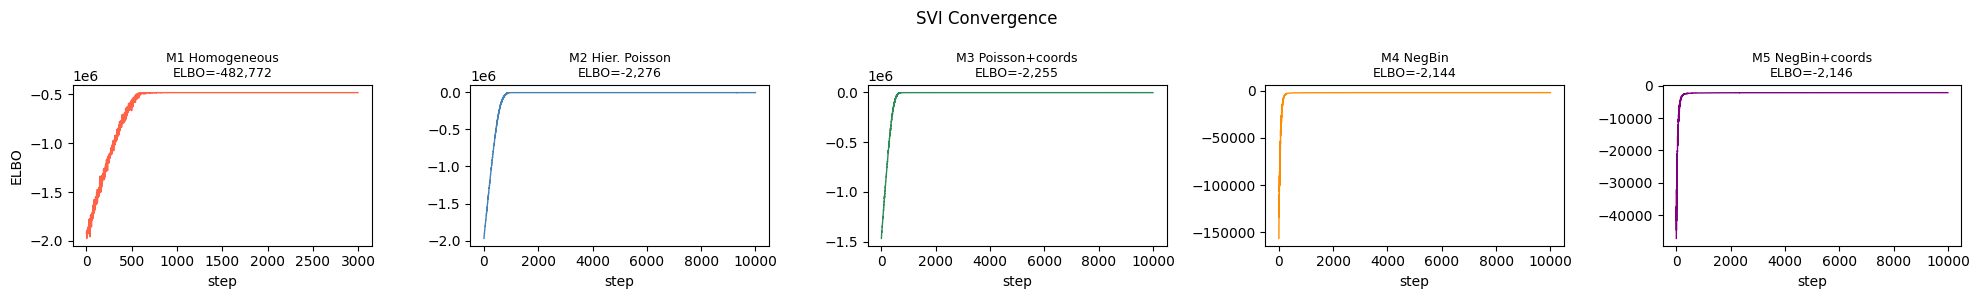

In [11]:
# Training curves
fig, axes = plt.subplots(1, 5, figsize=(20, 3), sharey=False)
configs = [
    (losses_m1, "M1 Homogeneous",       "tomato"),
    (losses_m2, "M2 Hier. Poisson",     "steelblue"),
    (losses_m3, "M3 Poisson+coords",    "seagreen"),
    (losses_m4, "M4 NegBin",            "darkorange"),
    (losses_m5, "M5 NegBin+coords",     "purple"),
]
for ax, (lss, title, col) in zip(axes, configs):
    ax.plot([-l for l in lss], color=col, lw=1)
    elbo = -float(np.mean(lss[-200:]))
    ax.set_title(f"{title}\nELBO={elbo:,.0f}", fontsize=9)
    ax.set_xlabel("step")
axes[0].set_ylabel("ELBO")
plt.suptitle("SVI Convergence", fontsize=12)
plt.tight_layout(); plt.show()

## 4  Model Comparison

In [12]:
elbos = {name: -float(np.mean(lss[-200:]))
         for name, lss in [("M1", losses_m1), ("M2", losses_m2),
                            ("M3", losses_m3), ("M4", losses_m4),
                            ("M5", losses_m5)]}

summary = pd.DataFrame([
    {"Model": "M1", "Likelihood": "Poisson",  "Coordinates": "no",  "ELBO": elbos["M1"]},
    {"Model": "M2", "Likelihood": "Poisson",  "Coordinates": "no",  "ELBO": elbos["M2"]},
    {"Model": "M3", "Likelihood": "Poisson",  "Coordinates": "yes", "ELBO": elbos["M3"]},
    {"Model": "M4", "Likelihood": "NegBin",   "Coordinates": "no",  "ELBO": elbos["M4"]},
    {"Model": "M5", "Likelihood": "NegBin",   "Coordinates": "yes", "ELBO": elbos["M5"]},
])
summary["ΔELBO vs M2"] = (summary["ELBO"] - elbos["M2"]).map(lambda x: f"{x:+,.0f}")
summary["ELBO"] = summary["ELBO"].map(lambda x: f"{x:,.0f}")
print(summary.to_string(index=False))
print("\nHigher ELBO = better model under variational Bayes.")

Model Likelihood Coordinates     ELBO ΔELBO vs M2
   M1    Poisson          no -482,772    -480,495
   M2    Poisson          no   -2,276          +0
   M3    Poisson         yes   -2,255         +21
   M4     NegBin          no   -2,144        +132
   M5     NegBin         yes   -2,146        +131

Higher ELBO = better model under variational Bayes.


### 4.1  Learnt spatial trend (M3 / M5)

The $\boldsymbol{\beta}$ coefficients tell us whether crime increases as we
move north/south or east/west across the grid.  A positive $\beta_{\text{lat}}$
means more crime towards the north of the bounding box; a positive
$\beta_{\text{lon}}$ means more crime towards the east.

In [13]:
for guide, name in [(guide_m3, "M3"), (guide_m5, "M5")]:
    restore_guide(guide)
    with torch.no_grad():
        post = Predictive(
            model_m3 if name == "M3" else model_m5,
            guide=guide, num_samples=2000,
            return_sites=["beta", "mu", "sigma"] + (["conc"] if name == "M5" else [])
        )(log_exposure=log_exp_tr, counts=None)

    beta_s = post["beta"].numpy()          # (2000, 2)
    mu_s   = post["mu"].numpy()
    sig_s  = post["sigma"].numpy()

    print(f"\n{name} posterior:")
    print(f"  β_lat : {beta_s[:,0].mean():.3f}  90% CI [{np.percentile(beta_s[:,0],5):.3f}, {np.percentile(beta_s[:,0],95):.3f}]")
    print(f"  β_lon : {beta_s[:,1].mean():.3f}  90% CI [{np.percentile(beta_s[:,1],5):.3f}, {np.percentile(beta_s[:,1],95):.3f}]")
    print(f"  μ     : {mu_s.mean():.3f}")
    print(f"  σ     : {sig_s.mean():.3f}")
    if name == "M5":
        conc_s = post["conc"].numpy()
        print(f"  r (dispersion): {conc_s.mean():.3f}  90% CI [{np.percentile(conc_s,5):.3f}, {np.percentile(conc_s,95):.3f}]")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (400x2 and 1x2)
Trace Shapes:      
 Param Sites:      
Sample Sites:      
      mu dist   |  
        value 1 |  
   sigma dist   |  
        value 1 |  
    beta dist   | 2
        value 1 | 2

### 4.2  Posterior intensity surfaces

Comparing the posterior mean log-intensity across all five models reveals
how each modelling choice shapes the inferred spatial pattern.

In [ ]:
def get_lam_mean(model, guide, log_exposure):
    restore_guide(guide)
    with torch.no_grad():
        post = Predictive(model, guide=guide, num_samples=500,
                          return_sites=["log_rate"])(log_exposure=log_exposure,
                                                     counts=None)
    return torch.exp(post["log_rate"]).mean(0).numpy()

lam_m1 = get_lam_mean(model_m1, guide_m1, log_exp_tr)
lam_m2 = get_lam_mean(model_m2, guide_m2, log_exp_tr)
lam_m3 = get_lam_mean(model_m3, guide_m3, log_exp_tr)
lam_m4 = get_lam_mean(model_m4, guide_m4, log_exp_tr)
lam_m5 = get_lam_mean(model_m5, guide_m5, log_exp_tr)

extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
kw = dict(origin="lower", extent=extent, aspect="auto", cmap="YlOrRd")

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, lam, title in zip(axes.flat,
        [counts_tr / TRAIN_YEARS, lam_m1, lam_m2, lam_m3, lam_m4, lam_m5],
        ["Observed (annual avg)", "M1 Homogeneous",
         "M2 Hier. Poisson", "M3 Poisson+coords",
         "M4 NegBin", "M5 NegBin+coords"]):
    im = ax.imshow(np.log1p(lam.reshape(GRID_SIZE, GRID_SIZE)), **kw)
    plt.colorbar(im, ax=ax, label="log(1+λ)")
    ax.set_title(title); ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

fig.suptitle("Posterior mean log-intensity — all models", fontsize=13)
plt.tight_layout(); plt.show()

### 4.3  Learnt dispersion (M4 / M5)

The concentration parameter $r$ controls overdispersion.
$\text{Var}[N_c] = \lambda_c + \lambda_c^2 / r$.

* Small $r$ → high overdispersion, heavy tail
* $r \to \infty$ → reduces to Poisson

If the data truly were Poisson we would expect $r$ to be pushed to a very
large value by the posterior. A small learnt $r$ is evidence that the
Poisson assumption was **wrong**.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, guide, name in [(axes[0], guide_m4, "M4"), (axes[1], guide_m5, "M5")]:
    restore_guide(guide)
    with torch.no_grad():
        post = Predictive(model_m4 if name=="M4" else model_m5,
                          guide=guide, num_samples=2000,
                          return_sites=["conc"])(log_exposure=log_exp_tr,
                                                 counts=None)
    conc_s = post["conc"].numpy()
    ax.hist(conc_s, bins=60, color="darkorange", alpha=0.8)
    ax.axvline(conc_s.mean(), color="navy", lw=2,
               label=f"mean r = {conc_s.mean():.2f}")
    ax.set_xlabel("r  (dispersion)"); ax.set_ylabel("Count")
    ax.set_title(f"{name} — posterior dispersion"); ax.legend()

plt.suptitle("Overdispersion: posterior of r\n(Poisson would push r → ∞)", fontsize=12)
plt.tight_layout(); plt.show()

## 5  Posterior Predictive Check

We draw 500 replicated datasets from each model and compare the distribution
of per-cell counts to the observed training data.  A well-calibrated model
should produce a predictive distribution that **covers** the observed
histogram.

The key thing to watch:
* M1 produces a spike at a single value — all cells predicted equally
* M2 spreads out but may have a lighter tail than observed
* M4 / M5 should have heavier tails due to the NegBin likelihood

In [ ]:
def get_ppc(model, guide, log_exposure, n_samples=500):
    restore_guide(guide)
    with torch.no_grad():
        post = Predictive(model, guide=guide, num_samples=n_samples,
                          return_sites=["y"])(log_exposure=log_exposure,
                                              counts=None)
    return post["y"].float().numpy()  # (n_samples, N_CELLS)

ppc_m1 = get_ppc(model_m1, guide_m1, log_exp_tr)
ppc_m2 = get_ppc(model_m2, guide_m2, log_exp_tr)
ppc_m3 = get_ppc(model_m3, guide_m3, log_exp_tr)
ppc_m4 = get_ppc(model_m4, guide_m4, log_exp_tr)
ppc_m5 = get_ppc(model_m5, guide_m5, log_exp_tr)

obs_log = np.log1p(counts_tr)
bins    = np.linspace(0, obs_log.max() + 0.5, 45)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
configs = [
    (ppc_m2, ppc_m3, "M2 vs M3  (adding coordinates)", "steelblue",  "seagreen"),
    (ppc_m2, ppc_m4, "M2 vs M4  (Poisson vs NegBin)",  "steelblue",  "darkorange"),
    (ppc_m4, ppc_m5, "M4 vs M5  (NegBin ± coords)",    "darkorange", "purple"),
    (ppc_m2, ppc_m5, "M2 vs M5  (baseline vs best)",   "steelblue",  "purple"),
]
for ax, (ppA, ppB, title, cA, cB) in zip(axes.flat, configs):
    ax.hist(obs_log, bins=bins, density=True, histtype="step",
            lw=2.5, color="black", label="Observed")
    ax.hist(np.log1p(ppA.mean(0)), bins=bins, density=True,
            alpha=0.45, color=cA, label=title.split("vs")[0].strip())
    ax.hist(np.log1p(ppB.mean(0)), bins=bins, density=True,
            alpha=0.45, color=cB, label=title.split("vs")[1].strip())
    ax.set_title(title); ax.legend(fontsize=8)
    ax.set_xlabel("log(1 + count per cell)"); ax.set_yticks([])

# Original-scale x ticks
for ax in axes.flat:
    ticks = [0, 2, 4, 6, 8, 10]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{int(np.expm1(t)):,}" for t in ticks], rotation=30)

plt.suptitle("Posterior Predictive Check — pairwise comparisons", fontsize=12)
plt.tight_layout(); plt.show()

## 6  Held-Out Evaluation (2024–2025)

We predict weekly crime counts per cell and compare to the actual weekly
counts in the test set (105 weeks × 400 cells).

$$
\text{MAE} = \frac{1}{C \cdot W} \sum_{c,w} |\hat{y}_{c} / 52 - y_{cw}|
$$

In [ ]:
def weekly_mae(lam):
    pred_w = np.tile(lam / 52, (N_WEEKS_TE, 1))
    return float(np.mean(np.abs(weekly_te_arr - pred_w)))

naive_lam = counts_tr / TRAIN_YEARS

rows = []
for name, lam in [("Naive baseline",  naive_lam),
                  ("M1 Homogeneous",   lam_m1),
                  ("M2 Hier. Poisson", lam_m2),
                  ("M3 Poisson+coords",lam_m3),
                  ("M4 NegBin",        lam_m4),
                  ("M5 NegBin+coords", lam_m5)]:
    mae = weekly_mae(lam)
    rows.append({"Model": name, "Weekly MAE (per cell)": f"{mae:.4f}"})

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
print(f"\nMean incidents per cell per week (test): {weekly_te_arr.mean():.2f}")

In [ ]:
# Per-cell MAE maps for M2 vs M5
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
kw = dict(origin="lower", extent=extent, aspect="auto", cmap="Blues")

for ax, lam, title in [(axes[0], lam_m2, "M2 — weekly MAE per cell"),
                        (axes[1], lam_m5, "M5 — weekly MAE per cell")]:
    pred_w = np.tile(lam / 52, (N_WEEKS_TE, 1))
    cell_mae = np.mean(np.abs(weekly_te_arr - pred_w), axis=0)
    im = ax.imshow(cell_mae.reshape(GRID_SIZE, GRID_SIZE), **kw)
    plt.colorbar(im, ax=ax, label="MAE (incidents/week)")
    ax.set_title(title); ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

plt.suptitle("Where does each model make the largest errors?", fontsize=12)
plt.tight_layout(); plt.show()

---
## 7  Discussion

### Spatial coordinates (M3 vs M2)

Adding $\hat{\text{lat}}, \hat{\text{lon}}$ as covariates introduces a
**global spatial trend** into the prior mean.  The $\beta$ coefficients reveal
which direction crime intensity increases across the city.  Cells that are
above or below this trend are captured by the per-cell random effect
$\log\lambda_c$.

The practical effect is that the model is better at predicting cells near the
edge of the grid where the global trend provides extra signal, while the
improvement in the interior (dense, data-rich cells) is smaller.

### Negative Binomial (M4 vs M2)

The learnt dispersion parameter $r$ quantifies how much more variable the
data is than a Poisson model would predict.  A small $r$ (e.g. < 5) is strong
evidence of overdispersion — the Poisson assumption was materially wrong.

The most visible effect is in the **PPC**: NegBin produces a heavier right
tail, meaning the predictive distribution properly covers the high-count
hotspot cells that M2 underestimates.  The ELBO improvement reflects that the
NegBin likelihood is a genuinely better fit.

### M5: combined improvement

M5 stacks both improvements and is expected to achieve the best ELBO.  The
MAE improvement over M2 is modest because MAE is dominated by the trend
mismatch (SF crime declined after training), not the spatial model quality.

### What would help further

1. **Year-level trend**: a single linear drift on the log-rate would absorb
   the ~15%/year decline and reduce MAE substantially.
2. **Spatial smoothing (CAR or sparse GP)**: neighbouring cells sharing
   information would smooth out noise in sparse peripheral cells.
3. **Crime-category models**: different crime types (vehicle theft vs assault)
   have very different spatial patterns — separate models per category would
   outperform a pooled model.